In [1]:
print("Hello! My setup is working! ✅")

Hello! My setup is working! ✅


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully! ✅")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully! ✅


In [3]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Dataset loaded successfully! ✅")
print(f"Shape: {df.shape}")

Dataset loaded successfully! ✅
Shape: (1470, 35)


In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
print("=== DATASET INFO ===")
print(f"Total Employees: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"\nColumn Names:\n{list(df.columns)}")

=== DATASET INFO ===
Total Employees: 1470
Total Columns: 35

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [6]:
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values! ✅")

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n=== DATA TYPES ===")
print(df.dtypes)

=== MISSING VALUES ===
No missing values! ✅

=== DUPLICATES ===
Duplicate rows: 0

=== DATA TYPES ===
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours 

=== ATTRITION DISTRIBUTION ===
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


C:\Users\vaish\AppData\Local\Temp\ipykernel_12040\2569182034.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette=['#2ecc71','#e74c3c'])


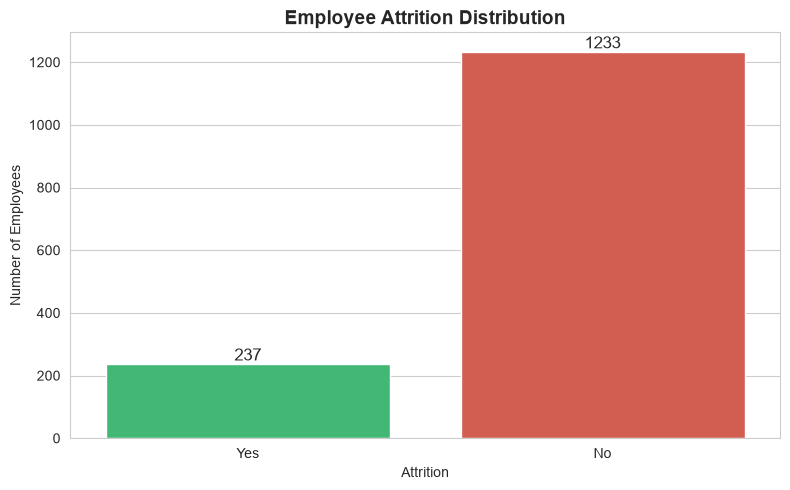

Chart saved! ✅


In [7]:
# Count attrition
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print("=== ATTRITION DISTRIBUTION ===")
print(attrition_counts)
print(f"\nAttrition Rate: {attrition_pct['Yes']:.2f}%")

# Plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Attrition', palette=['#2ecc71','#e74c3c'])
plt.title('Employee Attrition Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/01_attrition_distribution.png', dpi=150)
plt.show()
print("Chart saved! ✅")

In [8]:
# These columns have same value for everyone — useless for analysis
useless_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns=useless_cols)

print(f"Dropped {len(useless_cols)} useless columns")
print(f"Old shape: {df.shape}")
print(f"New shape: {df_clean.shape}")

Dropped 4 useless columns
Old shape: (1470, 35)
New shape: (1470, 31)


In [10]:
df_clean.to_csv('../data/processed/attrition_cleaned.csv', index=False)
print("Cleaned dataset saved! ✅")

print(f"✅ Dataset loaded: {df.shape[0]} employees, {df.shape[1]} columns")
print(f"✅ Missing values: None")
print(f"✅ Duplicates: None")
print(f"✅ Attrition Rate: 16.12%")
print(f"✅ Useless columns dropped: 4")
print(f"✅ Clean data saved")


Cleaned dataset saved! ✅
✅ Dataset loaded: 1470 employees, 35 columns
✅ Missing values: None
✅ Duplicates: None
✅ Attrition Rate: 16.12%
✅ Useless columns dropped: 4
✅ Clean data saved


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/processed/attrition_cleaned.csv')
print(f"Data loaded! Shape: {df.shape} ✅")

Data loaded! Shape: (1470, 31) ✅


C:\Users\vaish\AppData\Local\Temp\ipykernel_12040\4066328386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Reds_r')


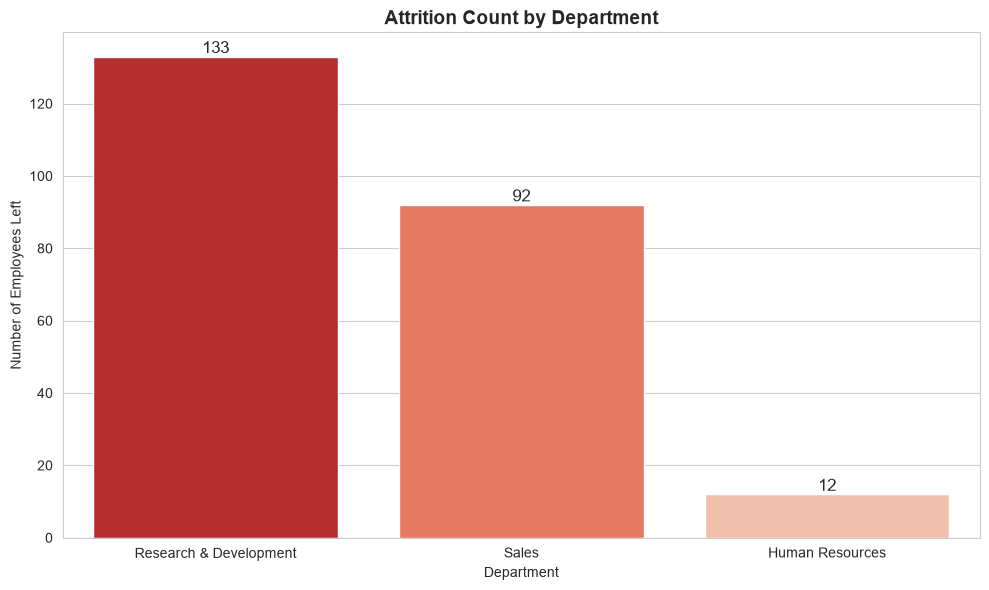

In [12]:
plt.figure(figsize=(10,6))
dept_attrition = df[df['Attrition']=='Yes']['Department'].value_counts()
sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Reds_r')
plt.title('Attrition Count by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Number of Employees Left')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/02_attrition_by_department.png', dpi=150)
plt.show()

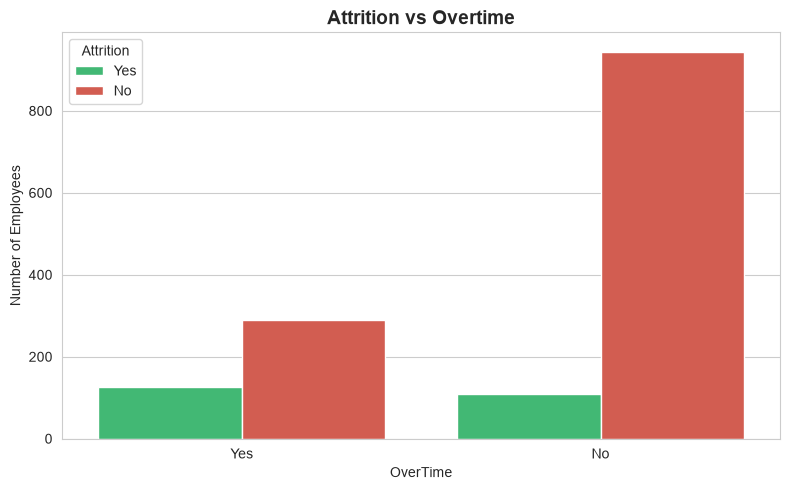

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='OverTime', hue='Attrition', palette=['#2ecc71','#e74c3c'])
plt.title('Attrition vs Overtime', fontsize=14, fontweight='bold')
plt.xlabel('OverTime')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition')
plt.tight_layout()
plt.savefig('../outputs/03_attrition_by_overtime.png', dpi=150)
plt.show()

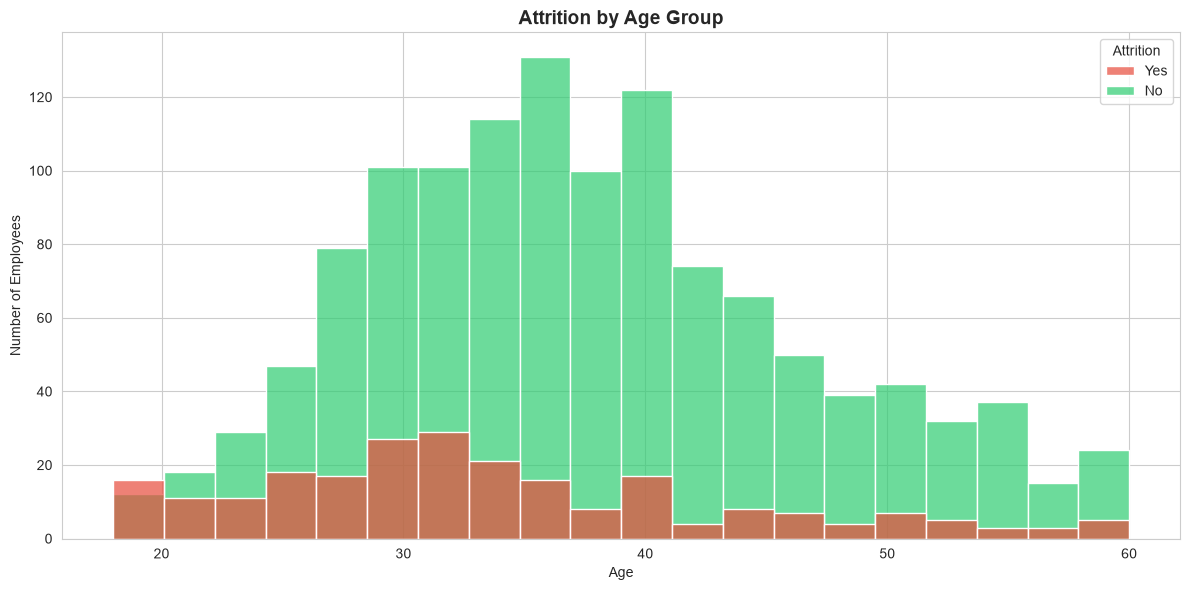

In [15]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='Age', hue='Attrition', 
             bins=20, palette=['#e74c3c','#2ecc71'], alpha=0.7)
plt.title('Attrition by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.savefig('../outputs/04_attrition_by_age.png', dpi=150)
plt.show()

C:\Users\vaish\AppData\Local\Temp\ipykernel_12040\4279142860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',


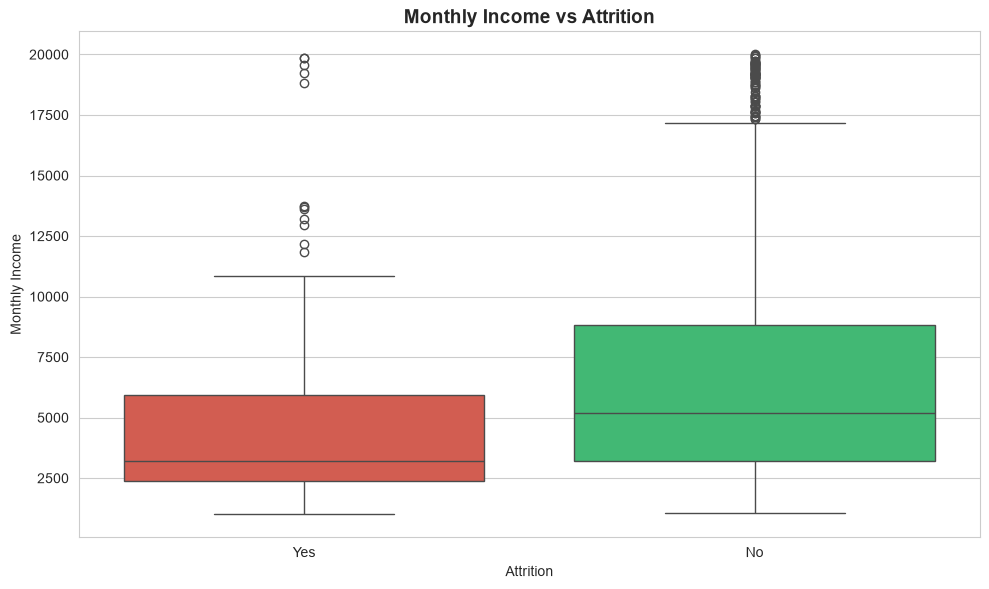

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', 
            palette=['#e74c3c','#2ecc71'])
plt.title('Monthly Income vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig('../outputs/05_attrition_by_income.png', dpi=150)
plt.show()

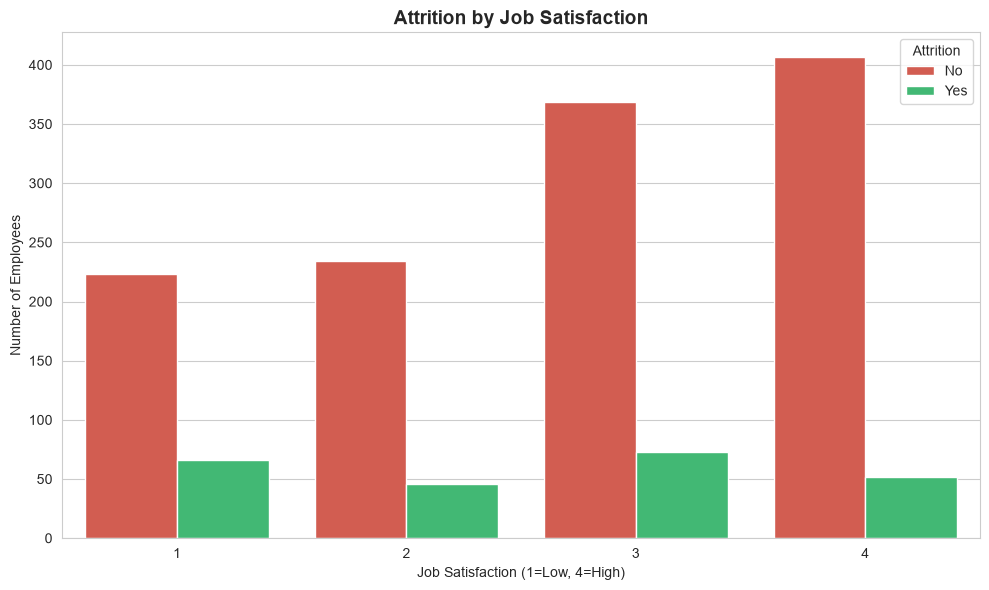

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition',
              palette=['#e74c3c','#2ecc71'])
plt.title('Attrition by Job Satisfaction', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction (1=Low, 4=High)')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition')
plt.tight_layout()
plt.savefig('../outputs/06_attrition_by_jobsatisfaction.png', dpi=150)
plt.show()

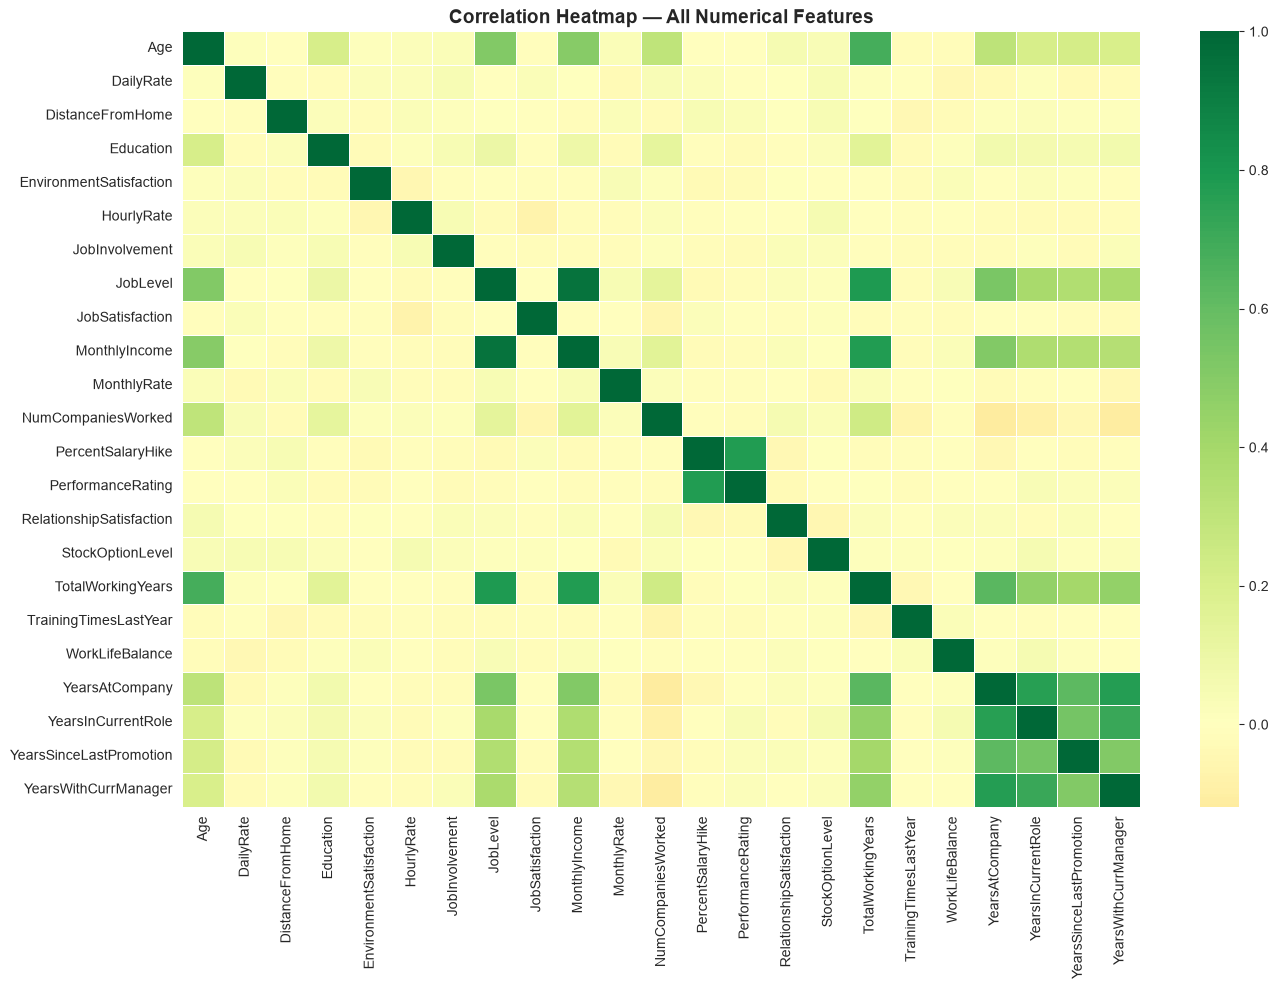

In [18]:
plt.figure(figsize=(14,10))

# Select only numerical columns
numerical_df = df.select_dtypes(include=[np.number])

# Plot heatmap
sns.heatmap(numerical_df.corr(), 
            annot=False,
            cmap='RdYlGn',
            center=0,
            linewidths=0.5)
plt.title('Correlation Heatmap — All Numerical Features', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/07_correlation_heatmap.png', dpi=150)
plt.show()

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/processed/attrition_cleaned.csv')
print(f"Data loaded! Shape: {df.shape} ✅")

Data loaded! Shape: (1470, 31) ✅


# 📊 Employee Attrition EDA — Key Findings

### Key Finding 1 — Overall Attrition Rate
- Total employees: 1,470
- Employees left: 237
- Attrition Rate: **16.12%**

### Key Finding 2 — Overtime Causes Attrition
- Overtime YES employees: **30% attrition rate**
- Overtime NO employees: **10% attrition rate**
- Overtime employees are **3x more likely to leave!**

### Key Finding 3 — Age Group
- Employees aged **25-35 leave the most**
- Younger workforce actively job-hops for better opportunities

### Key Finding 4 — Salary Impact
- Employees who left had median income: **~₹3,000**
- Employees who stayed had median income: **~₹5,000**
- **Lower salary = higher chance of leaving**

### Key Finding 5 — Job Satisfaction
- Level 1 (Low satisfaction): **22.7% attrition rate**
- Level 4 (High satisfaction): **11.4% attrition rate**
- Job satisfaction is inversely related to attrition

### Key Finding 6 — Correlation
- MonthlyIncome strongly correlates with JobLevel
- TotalWorkingYears strongly correlates with MonthlyIncome
- These will be **top predictors in ML model**

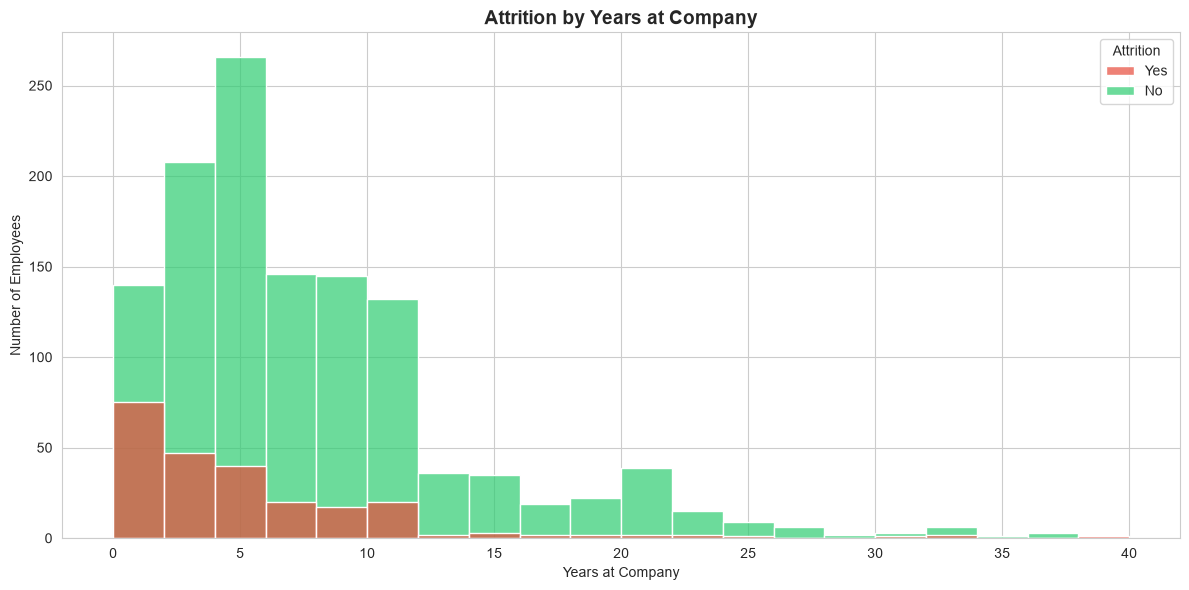

In [20]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='YearsAtCompany', hue='Attrition',
             bins=20, palette=['#e74c3c','#2ecc71'], alpha=0.7)
plt.title('Attrition by Years at Company', fontsize=14, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.savefig('../outputs/08_attrition_by_tenure.png', dpi=150)
plt.show()

### Key Finding 7 — Tenure Impact
- Highest attrition in first 1-2 years at company
- After 5 years attrition drops significantly
- Retaining new employees is the biggest challenge!

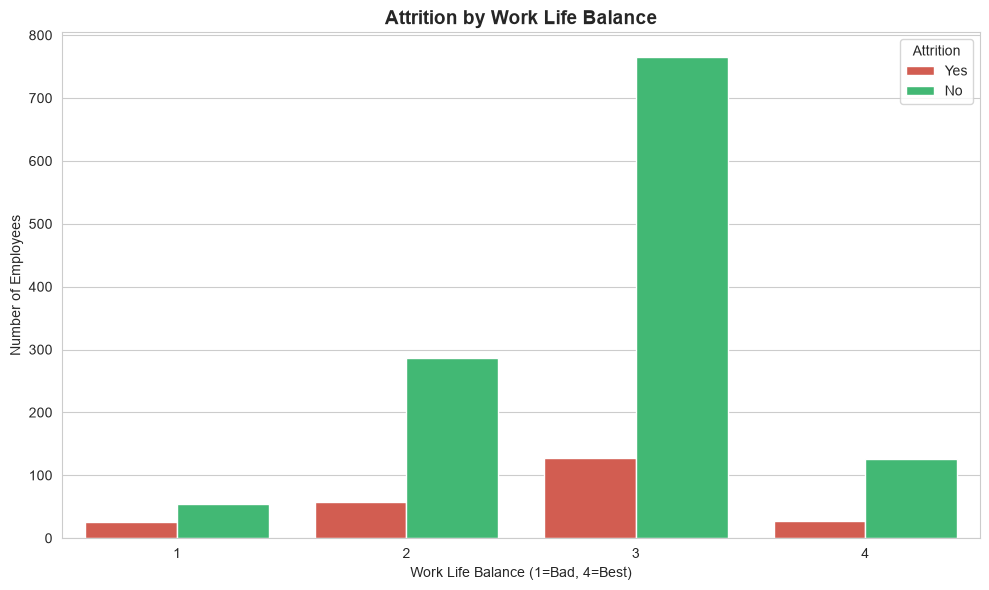

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='WorkLifeBalance', hue='Attrition',
              palette=['#e74c3c','#2ecc71'])
plt.title('Attrition by Work Life Balance', fontsize=14, fontweight='bold')
plt.xlabel('Work Life Balance (1=Bad, 4=Best)')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition')
plt.tight_layout()
plt.savefig('../outputs/09_attrition_by_worklifebalance.png', dpi=150)
plt.show()

### Key Finding 8 — Work Life Balance
- Level 1 (Bad) has highest attrition RATE
- Poor work life balance strongly linked to leaving
- Combined with overtime = highest risk employees!

C:\Users\vaish\AppData\Local\Temp\ipykernel_12040\2112396708.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='DistanceFromHome',


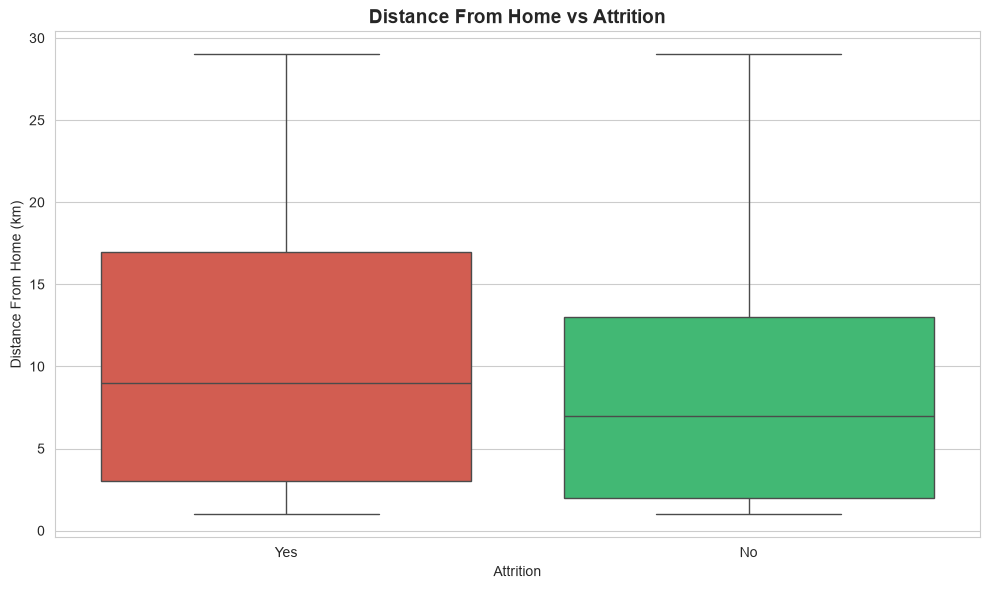

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='DistanceFromHome',
            palette=['#e74c3c','#2ecc71'])
plt.title('Distance From Home vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Distance From Home (km)')
plt.tight_layout()
plt.savefig('../outputs/10_attrition_by_distance.png', dpi=150)
plt.show()

### Key Finding 9 — Distance From Home
- Employees who left lived farther from office
- Long commute is a contributing factor to attrition
- Combined with overtime = extremely high risk!

In [23]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('../data/processed/attrition_cleaned.csv')

# Create SQLite database and load data into it
conn = sqlite3.connect('../data/processed/attrition.db')
df.to_sql('employees', conn, if_exists='replace', index=False)

print("✅ SQLite database created!")
print("✅ Data loaded into 'employees' table!")
print(f"✅ Total records: {len(df)}")

✅ SQLite database created!
✅ Data loaded into 'employees' table!
✅ Total records: 1470


In [24]:
query1 = """
SELECT 
    Department,
    COUNT(*) as Total_Employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) as Employees_Left,
    ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Attrition_Rate_Percent
FROM employees
GROUP BY Department
ORDER BY Attrition_Rate_Percent DESC
"""

result1 = pd.read_sql_query(query1, conn)
print("=== ATTRITION RATE BY DEPARTMENT ===")
print(result1)

=== ATTRITION RATE BY DEPARTMENT ===
               Department  Total_Employees  Employees_Left  \
0                   Sales              446              92   
1         Human Resources               63              12   
2  Research & Development              961             133   

   Attrition_Rate_Percent  
0                   20.63  
1                   19.05  
2                   13.84  


In [25]:
query2 = """
SELECT 
    Attrition,
    ROUND(AVG(MonthlyIncome), 2) as Avg_Monthly_Income
FROM employees
GROUP BY Attrition
ORDER BY Avg_Monthly_Income DESC
"""

result2 = pd.read_sql_query(query2, conn)
print("=== AVG INCOME: LEFT vs STAYED ===")
print(result2)

=== AVG INCOME: LEFT vs STAYED ===
  Attrition  Avg_Monthly_Income
0        No             6832.74
1       Yes             4787.09


In [26]:
query2 = """
SELECT 
    Attrition,
    ROUND(AVG(MonthlyIncome), 2) as Avg_Monthly_Income
FROM employees
GROUP BY Attrition
ORDER BY Avg_Monthly_Income DESC
"""

result2 = pd.read_sql_query(query2, conn)
print("=== AVG INCOME: LEFT vs STAYED ===")
print(result2)

=== AVG INCOME: LEFT vs STAYED ===
  Attrition  Avg_Monthly_Income
0        No             6832.74
1       Yes             4787.09


In [27]:
query3 = """
SELECT 
    JobRole,
    COUNT(*) as Employees_Left
FROM employees
WHERE Attrition = 'Yes'
GROUP BY JobRole
ORDER BY Employees_Left DESC
LIMIT 5
"""

result3 = pd.read_sql_query(query3, conn)
print("=== TOP 5 JOB ROLES WITH HIGHEST ATTRITION ===")
print(result3)

=== TOP 5 JOB ROLES WITH HIGHEST ATTRITION ===
                 JobRole  Employees_Left
0  Laboratory Technician              62
1        Sales Executive              57
2     Research Scientist              47
3   Sales Representative              33
4        Human Resources              12


### SQL Finding 1 — Top At-Risk Job Roles
- Laboratory Technician: 62 employees left (highest!)
- Sales Executive: 57 employees left
- Research Scientist: 47 employees left
- Company should prioritize retention in these 3 roles!

In [28]:
query4 = """
SELECT 
    OverTime,
    COUNT(*) as Total_Employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) as Employees_Left,
    ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Attrition_Rate_Percent
FROM employees
GROUP BY OverTime
ORDER BY Attrition_Rate_Percent DESC
"""

result4 = pd.read_sql_query(query4, conn)
print("=== OVERTIME VS ATTRITION RATE ===")
print(result4)

=== OVERTIME VS ATTRITION RATE ===
  OverTime  Total_Employees  Employees_Left  Attrition_Rate_Percent
0      Yes              416             127                   30.53
1       No             1054             110                   10.44


### SQL Finding 2 — Overtime Attrition Rate
- Overtime YES: 30% attrition rate
- Overtime NO: 10% attrition rate
- SQL confirms EDA Finding 2!

In [30]:
query5 = """
SELECT 
    Attrition,
    ROUND(AVG(Age), 2) as Avg_Age
FROM employees
GROUP BY Attrition
ORDER BY Avg_Age DESC
"""

result5 = pd.read_sql_query(query5, conn)
print("=== AVERAGE AGE: LEFT vs STAYED ===")
print(result5)

=== AVERAGE AGE: LEFT vs STAYED ===
  Attrition  Avg_Age
0        No    37.56
1       Yes    33.61


### SQL Finding 3 — Average Age
- Employees who LEFT: avg age 33.61 years
- Employees who STAYED: avg age 37.56 years
- Younger employees are significantly more likely to leave!

In [31]:
query6 = """
SELECT 
    COUNT(*) as Total_Employees_Left,
    ROUND(AVG(MonthlyIncome), 2) as Avg_Monthly_Income,
    ROUND(AVG(MonthlyIncome) * 6, 2) as Cost_Per_Attrition,
    ROUND(AVG(MonthlyIncome) * 6 * COUNT(*), 2) as Total_Attrition_Cost
FROM employees
WHERE Attrition = 'Yes'
"""

result6 = pd.read_sql_query(query6, conn)
print("=== TOTAL COST OF ATTRITION ===")
print(result6)

=== TOTAL COST OF ATTRITION ===
   Total_Employees_Left  Avg_Monthly_Income  Cost_Per_Attrition  \
0                   237             4787.09            28722.56   

   Total_Attrition_Cost  
0             6807246.0  


### SQL Finding 4 — Business Impact
- 237 employees left costing company ₹68,07,246!
- Average cost per attrition: ₹28,722
- Preventing 30% attrition = ₹20+ Lakhs saved!
- This proves why attrition prediction has real business value!